# Custom BERT Model Implementation (PyTorch)
Bu notebookta sıfırdan bir BERT (Bidirectional Encoder Representations from Transformers) modeli mimarisini PyTorch kullanarak oluşturuyoruz.

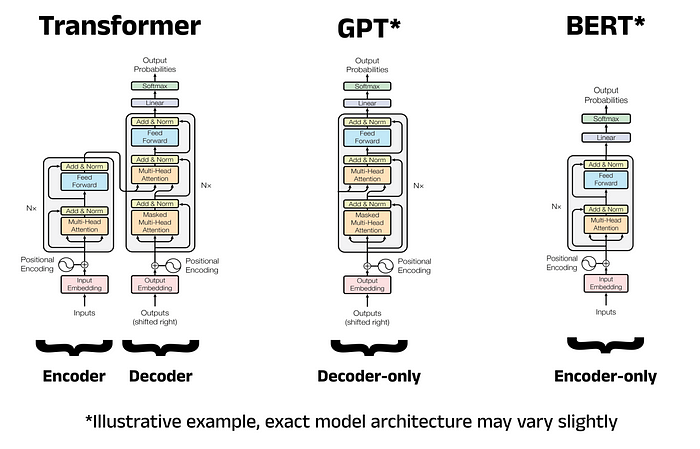


In [2]:
import torch
import torch.nn as nn
import math

### 1. Multi-Head Attention
Öz-dikkat (self-attention) mekanizmasını uygulayan modül.

In [ ]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0, "d_model num_heads'e kalansız bölünmeli"
        
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)
        
    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        attn_scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        if mask is not None:
            attn_scores = attn_scores.masked_fill(mask == 0, -1e9)
        attn_probs = torch.softmax(attn_scores, dim=-1)
        output = torch.matmul(attn_probs, V)
        return output
        
    def forward(self, q, k, v, mask=None):
        batch_size = q.size(0)
        
        Q = self.W_q(q).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        K = self.W_k(k).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        V = self.W_v(v).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        
        attn_output = self.scaled_dot_product_attention(Q, K, V, mask)
        attn_output = attn_output.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)
        
        return self.W_o(attn_output)

Test için kendi attention

### 2. İleri Beslemeli Sinir Ağı (Feed Forward Space)
Dikkat mekanizmasından sonraki bölüm.

In [ ]:
class PositionwiseFeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff) # 1024 x 256
        self.linear2 = nn.Linear(d_ff, d_model) # 256 x 1024
        self.dropout = nn.Dropout(dropout)
        self.activation = nn.GELU()

    def forward(self, x):
        return self.linear2(self.dropout(self.activation(self.linear1(x))))

### 3. Encoder Layer (Kodlayıcı Katmanı)
Multi-Head Attention, residual bağlantılar ve Layer Normalization içerir.

In [ ]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.feed_forward = PositionwiseFeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x, mask):
        attn_output = self.self_attn(x, x, x, mask)
        x = self.norm1(x + self.dropout(attn_output))
        ff_output = self.feed_forward(x)
        x = self.norm2(x + self.dropout(ff_output))
        return x

### 4. Ana BERT Modeli
Token, Position ve Segment (cümle) embedding'lerini birleştirerek Encoder katmanlarından geçirir.

In [ ]:
class BERT(nn.Module):
    def __init__(self, vocab_size, d_model=768, num_layers=12, num_heads=12, d_ff=3072, max_seq_length=512, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        
        # Embedding katmanları
        self.token_embedding = nn.Embedding(vocab_size, d_model)
        self.position_embedding = nn.Embedding(max_seq_length, d_model)
        self.segment_embedding = nn.Embedding(2, d_model) # Sentence A (0) ve Sentence B (1)
        
        self.norm = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
        
        # N tane Encoder katmanı oluşturuyoruz
        self.layers = nn.ModuleList([EncoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)])
        
    def forward(self, x, segment_info, mask=None):
        seq_length = x.size(1)
        positions = torch.arange(seq_length, dtype=torch.long, device=x.device)
        positions = positions.unsqueeze(0).expand_as(x)
        
        # Embedding'leri topla
        idx_embeddings = self.token_embedding(x)
        pos_embeddings = self.position_embedding(positions)
        seg_embeddings = self.segment_embedding(segment_info)
        
        embeddings = idx_embeddings + pos_embeddings + seg_embeddings
        x = self.dropout(self.norm(embeddings))
        
        # Bütün katmanlardan sırayla geçir
        for layer in self.layers:
            x = layer(x, mask)
            
        return x

### 5. Örnek Kullanım
Modeli başlatıp sahte (dummy) verilerle çalıştıralım.

In [ ]:
# Parametreler
vocab_size = 30000
model = BERT(vocab_size=vocab_size, d_model=256, num_layers=4, num_heads=8, d_ff=1024)

# Sahte veriler (Batch size=2, Sequence length=32)
batch_size = 2
seq_length = 32

input_ids = torch.randint(0, vocab_size, (batch_size, seq_length))
segment_ids = torch.randint(0, 2, (batch_size, seq_length))
attention_mask = (input_ids > 0).unsqueeze(1).unsqueeze(2) # Basit bir attention mask

# İleri yönlü besleme (Forward pass)
output = model(input_ids, segment_ids, attention_mask)

print(f"Cevap Şekli (Output shape): {output.shape}") # Beklenen: [batch_size, seq_length, d_model]